# 04: Regression Model (Learning Outcome 3)

**Learning Outcome 3 (LO3):** Regression modeling and predictive analytics

**Model:** `yield_loss ~ monitoring_index + climate_risk + temp + precip`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [8]:
# Prepare regression data
X = valid_data[['monitoring_index', 'climate_risk_index']].values
y = valid_data['yield_loss_pct'].values

# Add constant
X = sm.add_constant(X)

# Fit OLS regression
model = sm.OLS(y, X).fit()

# Print summary
print("\n" + "="*70)
print("REGRESSION RESULTS: Yield Loss Model")
print("="*70)
print(model.summary())


REGRESSION RESULTS: Yield Loss Model
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                 -0.073
Method:                 Least Squares   F-statistic:                    0.2225
Date:                Mon, 20 Apr 2026   Prob (F-statistic):              0.802
Time:                        20:22:35   Log-Likelihood:                -75.968
No. Observations:                  24   AIC:                             157.9
Df Residuals:                      21   BIC:                             161.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         

In [7]:
# Prepare data for regression
valid_data = df.dropna(subset=['monitoring_index', 'climate_risk_index', 'yield_loss_pct'])
print(f"Valid data shape: {valid_data.shape}")

Valid data shape: (24, 15)


In [5]:
# Load the final dataset
df = pd.read_csv('../data/processed/final_dataset.csv')
print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

Dataset shape: (24, 15)

Columns: ['year', 'yield_kg_ha', 'area_harvested_ha', 'fertilizer_tonnes', 'irrigation_area_ha', 'temp_annual_mean', 'precip_annual_mean', 'monitoring_index', 'regular_monitoring', 'climate_risk_index', 'yield_loss_pct', 'response_time_days', 'effective_response', 'fertilizer_intensity_kg_ha', 'irrigation_ratio']

First few rows:
   year  yield_kg_ha  area_harvested_ha  fertilizer_tonnes  \
0  2000       3437.4           832000.0           246965.0   
1  2001       3522.8           765040.0           244068.0   
2  2002       3488.9           819590.0           285071.0   
3  2003       3369.6           911440.0           246225.0   
4  2004       3651.6           719690.0           258309.0   

   irrigation_area_ha  temp_annual_mean  precip_annual_mean  monitoring_index  \
0            570000.0         26.804617            2.869235            1.8267   
1            570000.0         26.303808            3.147315            1.9677   
2            570000.0      

FileNotFoundError: [Errno 2] No such file or directory: 'results/graphs/04_regression_diagnostics.png'

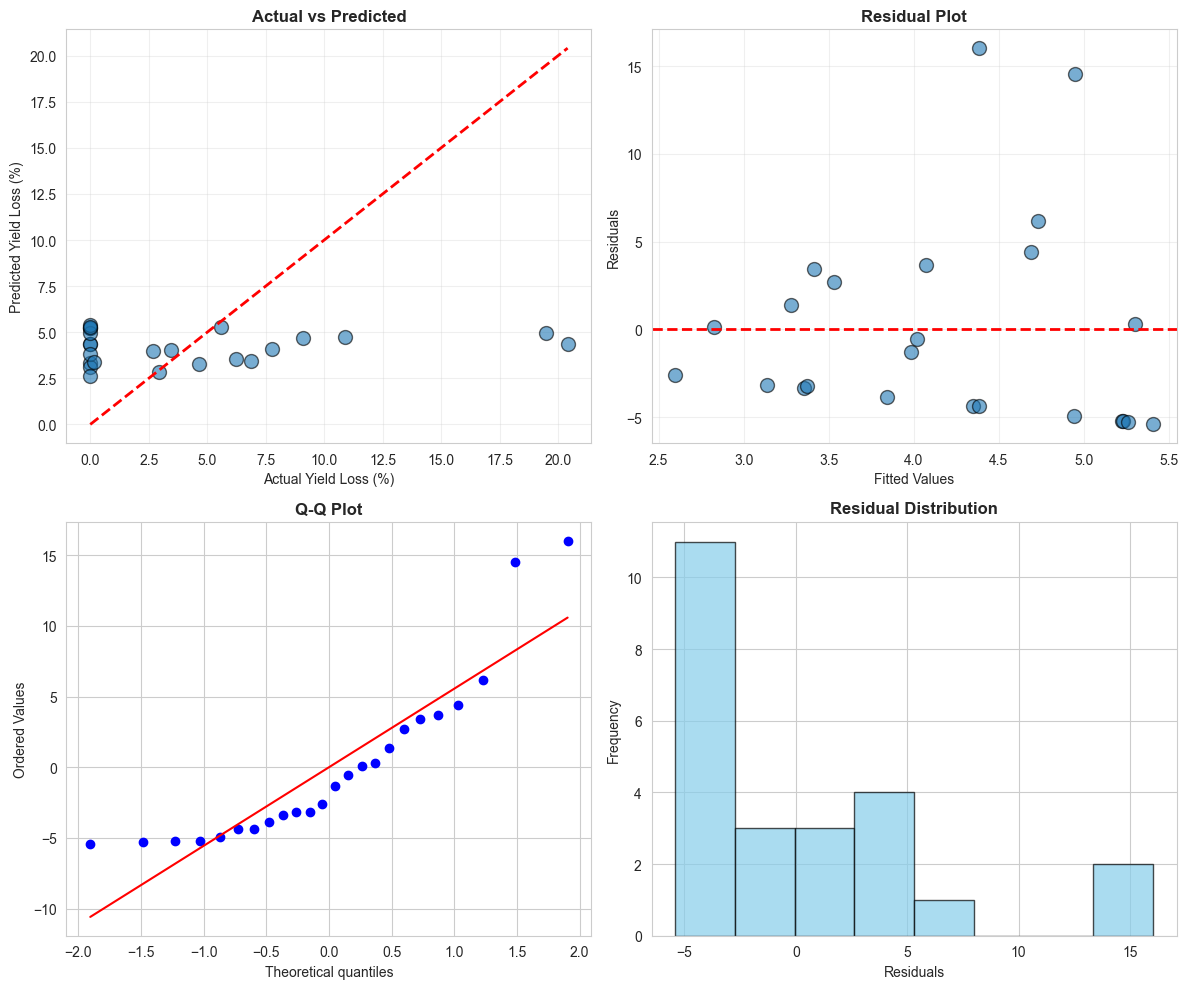

In [15]:
# Model diagnostics
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Actual vs Predicted
predictions = model.predict(X)
axes[0, 0].scatter(y, predictions, alpha=0.6, s=100, edgecolors='black')
axes[0, 0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Yield Loss (%)')
axes[0, 0].set_ylabel('Predicted Yield Loss (%)')
axes[0, 0].set_title('Actual vs Predicted', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals vs Fitted
residuals = model.resid
axes[0, 1].scatter(predictions, residuals, alpha=0.6, s=100, edgecolors='black')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Fitted Values')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residual Plot', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Q-Q Plot
stats.probplot(residuals, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot', fontweight='bold')

# 4. Histogram of Residuals
axes[1, 1].hist(residuals, bins=8, edgecolor='black', alpha=0.7, color='skyblue')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Residual Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('results/graphs/04_regression_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
import os
os.makedirs('../results/graphs', exist_ok=True)

In [13]:
# Model performance metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y, predictions)
rmse = np.sqrt(mean_squared_error(y, predictions))
mape = np.mean(np.abs((y - predictions) / (y + 1e-10))) * 100

print("\n=== Model Performance Metrics ===")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

# Summary dataframe
metrics_df = pd.DataFrame({
    'Metric': ['R-squared', 'Adj. R-squared', 'AIC', 'BIC', 'MAE', 'RMSE', 'MAPE (%)'],
    'Value': [f'{model.rsquared:.4f}', f'{model.rsquared_adj:.4f}', 
             f'{model.aic:.2f}', f'{model.bic:.2f}', f'{mae:.4f}', 
             f'{rmse:.4f}', f'{mape:.2f}']
})
print("\n")
print(metrics_df.to_string(index=False))


=== Model Performance Metrics ===
Mean Absolute Error (MAE): 4.3982
Root Mean Squared Error (RMSE): 5.7340
Mean Absolute Percentage Error (MAPE): 1988443783047.39%


        Metric            Value
     R-squared           0.0207
Adj. R-squared          -0.0725
           AIC           157.94
           BIC           161.47
           MAE           4.3982
          RMSE           5.7340
      MAPE (%) 1988443783047.39
